In [ ]:
import os

import pandas as pd
import numpy as np
import typing
import matplotlib.pyplot as plt

import keras
from keras import layers
from keras import ops

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.functional import mse_loss
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv

2024-12-15 10:48:53.428637: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-15 10:48:54.467312: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734230934.652941 1421377 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734230934.662885 1421377 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-15 10:48:55.188659: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [ ]:
route_distances = pd.read_csv("/staging/biology/u1307362/debby/datasets/PeMSD7_Full.zip/PeMSD7_W_228.csv", header=None).to_numpy()
speeds_array = pd.read_csv("/staging/biology/u1307362/debby/datasets/PeMSD7_Full.zip/PeMSD7_V_228.csv", header=None).to_numpy()

print(f"route_distances shape={route_distances.shape}")
print(f"speeds_array shape={speeds_array.shape}")

route_distances shape=(228, 228)
speeds_array shape=(12672, 228)


In [ ]:
def preprocess(data_array: torch.Tensor, train_size: float, val_size: float):
    """Splits data into train/val/test sets and normalizes the data.

    Args:
        data_array: Tensor of shape `(num_time_steps, num_routes)`
        train_size: Proportion of the dataset to include in the train split.
        val_size: Proportion of the dataset to include in the validation split.

    Returns:
        `train_tensor`, `val_tensor`, `test_tensor`
    """
    num_time_steps = data_array.size(0)
    num_train = int(num_time_steps * train_size)
    num_val = int(num_time_steps * val_size)

    # 切分數據
    train_tensor = data_array[:num_train]
    mean = train_tensor.mean(dim=0, keepdim=True)
    std = train_tensor.std(dim=0, keepdim=True)

    # 標準化數據
    train_tensor = (train_tensor - mean) / std
    val_tensor = (data_array[num_train : num_train + num_val] - mean) / std
    test_tensor = (data_array[num_train + num_val :] - mean) / std

    return train_tensor, val_tensor, test_tensor

# 轉換 speeds_array 成 PyTorch Tensor
speeds_tensor = torch.tensor(speeds_array, dtype=torch.float32)

# 使用 preprocess 函數
train_tensor, val_tensor, test_tensor = preprocess(speeds_tensor, train_size=0.7, val_size=0.2)

# 輸出結果
print(f"train set size: {train_tensor.shape}")
print(f"validation set size: {val_tensor.shape}")
print(f"test set size: {test_tensor.shape}")

torch.save(train_tensor, 'train_tensor.pt')
torch.save(val_tensor, 'val_tensor.pt')
torch.save(test_tensor, 'test_tensor.pt')

train set size: torch.Size([8870, 228])
validation set size: torch.Size([2534, 228])
test set size: torch.Size([1268, 228])


In [ ]:
from torch.utils.data import Dataset, DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, data_array, input_sequence_length, forecast_horizon):
        self.data_array = data_array
        self.input_sequence_length = input_sequence_length
        self.forecast_horizon = forecast_horizon
        self.num_samples = data_array.size(0) - input_sequence_length - forecast_horizon + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        inputs = self.data_array[idx: idx + self.input_sequence_length]  # shape: (input_sequence_length, num_routes)
        targets = self.data_array[idx + self.input_sequence_length: idx + self.input_sequence_length + self.forecast_horizon]
        return inputs, targets


# 設定參數
batch_size = 64
input_sequence_length = 36
forecast_horizon = 12
multi_horizon = True

# 創建 Dataset 和 DataLoader
train_dataset = TimeSeriesDataset(train_tensor, input_sequence_length, forecast_horizon)
val_dataset = TimeSeriesDataset(val_tensor, input_sequence_length, forecast_horizon)
test_dataset = TimeSeriesDataset(test_tensor, input_sequence_length, forecast_horizon)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")




Number of training samples: 8823
Number of validation samples: 2487
Number of test samples: 1221


In [ ]:
def compute_adjacency_matrix(
    route_distances: np.ndarray, sigma2: float, epsilon: float
):
    """Computes the adjacency matrix from distances matrix.

    It uses the formula in https://github.com/VeritasYin/STGCN_IJCAI-18#data-preprocessing to
    compute an adjacency matrix from the distance matrix.
    The implementation follows that paper.

    Args:
        route_distances: np.ndarray of shape `(num_routes, num_routes)`. Entry `i,j` of this array is the
            distance between roads `i,j`.
        sigma2: Determines the width of the Gaussian kernel applied to the square distances matrix.
        epsilon: A threshold specifying if there is an edge between two nodes. Specifically, `A[i,j]=1`
            if `np.exp(-w2[i,j] / sigma2) >= epsilon` and `A[i,j]=0` otherwise, where `A` is the adjacency
            matrix and `w2=route_distances * route_distances`

    Returns:
        A boolean graph adjacency matrix.
    """
    num_routes = route_distances.shape[0]
    route_distances = route_distances / 10000.0
    w2, w_mask = (
        route_distances * route_distances,
        np.ones([num_routes, num_routes]) - np.identity(num_routes),
    )
    return (np.exp(-w2 / sigma2) >= epsilon) * w_mask

In [ ]:
class GraphInfo:
    def __init__(self, edges: typing.Tuple[list, list], num_nodes: int):
        self.edges = edges
        self.num_nodes = num_nodes


sigma2 = 0.1
epsilon = 0.5
adjacency_matrix = compute_adjacency_matrix(route_distances, sigma2, epsilon)
node_indices, neighbor_indices = np.where(adjacency_matrix == 1) #找出圖中的所有邊
graph = GraphInfo(
    edges=(node_indices.tolist(), neighbor_indices.tolist()),
    num_nodes=adjacency_matrix.shape[0],
)
print(f"number of nodes: {graph.num_nodes}, number of edges: {len(graph.edges[0])}")

number of nodes: 228, number of edges: 1664


In [ ]:
class LSTM_GAT(nn.Module):
    def __init__(self, in_feat, out_feat, lstm_units, input_seq_len, output_seq_len, heads=4, dropout=0.1):
        super(LSTM_GAT, self).__init__()
        # Graph Attention Network layer
        self.gat = GATConv(in_channels=in_feat, out_channels=out_feat, heads=heads, concat=False, dropout=dropout)

        # LSTM layer
        self.lstm = nn.LSTM(input_size=out_feat, hidden_size=lstm_units, batch_first=True)

        # Dense layer
        self.dense = nn.Linear(lstm_units, output_seq_len)

    def forward(self, inputs, edge_index):
        """
        Args:
            inputs: Tensor of shape (batch_size, input_seq_len, num_nodes, in_feat)
            edge_index: Tensor of shape (2, num_edges) representing graph edges
        Returns:
            Tensor of shape (batch_size, output_seq_len, num_nodes)
        """
        batch_size, seq_len, num_nodes, in_feat = inputs.shape

        # Step 1: Combine batch and nodes dimensions for GAT
        inputs = inputs.permute(0, 2, 1, 3).reshape(batch_size * num_nodes, seq_len, in_feat)  # (batch_size * num_nodes, seq_len, in_feat)

        # Step 2: Process each time step through GAT
        edge_index_batch = edge_index.repeat(1, batch_size) + torch.arange(batch_size, device=inputs.device).repeat_interleave(edge_index.size(1)) * num_nodes
        gat_outputs = []

        for t in range(seq_len):
            x_t = inputs[:, t, :]  # Shape: (batch_size * num_nodes, in_feat)
            gat_out = self.gat(x_t, edge_index_batch)  # GAT Output: (batch_size * num_nodes, out_feat)
            gat_outputs.append(gat_out)

        gat_out = torch.stack(gat_outputs, dim=1)  # Shape: (batch_size * num_nodes, seq_len, out_feat)

        # Step 3: LSTM
        lstm_out, _ = self.lstm(gat_out)  # (batch_size * num_nodes, seq_len, lstm_units)
        lstm_out = lstm_out[:, -1, :]  # Use last time step output (batch_size * num_nodes, lstm_units)

        # Step 4: Dense layer
        dense_out = self.dense(lstm_out)  # (batch_size * num_nodes, output_seq_len)

        # Step 5: Reshape back to original shape
        output = dense_out.view(batch_size, num_nodes, -1)  # (batch_size, num_nodes, output_seq_len)
        output = output.permute(0, 2, 1)  # (batch_size, output_seq_len, num_nodes)

        return output


In [ ]:
# 模型參數
in_feat = 1
out_feat = 10
lstm_units = 64
input_seq_len = 36
output_seq_len = 12
heads = 4
dropout = 0.1
epochs = 100
learning_rate = 2e-3
weight_decay = 1e-2

# 設定設備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Graph Info
graph_info = GraphInfo(edges=(node_indices.tolist(), neighbor_indices.tolist()), num_nodes=route_distances.shape[0])
edge_index = torch.tensor(graph_info.edges, dtype=torch.long, device=device)

# 初始化模型
model = LSTM_GAT(
    in_feat=in_feat,
    out_feat=out_feat,
    lstm_units=lstm_units,
    input_seq_len=input_seq_len,
    output_seq_len=output_seq_len,
    heads=heads,
    dropout=dropout
).to(device)

# 優化器和損失函數
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss_fn = nn.MSELoss()

# Best validation loss initialization
best_val_loss = float('inf')

# ------------------ Training Loop with Validation ------------------
for epoch in range(1, epochs + 1):
    # ---- Training Phase ----
    model.train()
    total_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs.unsqueeze(-1), edge_index)  # Add input feature dimension
        loss = loss_fn(outputs, targets)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # ---- Validation Phase ----
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)
            val_outputs = model(val_inputs.unsqueeze(-1), edge_index)  # Add input feature dimension
            val_loss += loss_fn(val_outputs, val_targets).item()

    # ---- Epoch Results ----
    avg_train_loss = total_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch [{epoch}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Save the best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Best model saved at epoch {epoch} with Val Loss: {avg_val_loss:.4f}")

print("Training complete. Best model saved.")

Epoch [1/100], Train Loss: 0.6357, Val Loss: 0.6068
Best model saved at epoch 1 with Val Loss: 0.6068
Epoch [2/100], Train Loss: 0.5205, Val Loss: 0.5757
Best model saved at epoch 2 with Val Loss: 0.5757
Epoch [3/100], Train Loss: 0.4768, Val Loss: 0.4815
Best model saved at epoch 3 with Val Loss: 0.4815
Epoch [4/100], Train Loss: 0.4100, Val Loss: 0.4109
Best model saved at epoch 4 with Val Loss: 0.4109
Epoch [5/100], Train Loss: 0.3848, Val Loss: 0.4061
Best model saved at epoch 5 with Val Loss: 0.4061
Epoch [6/100], Train Loss: 0.3739, Val Loss: 0.4170
Epoch [7/100], Train Loss: 0.3690, Val Loss: 0.4063
Epoch [8/100], Train Loss: 0.3661, Val Loss: 0.4131
Epoch [9/100], Train Loss: 0.3626, Val Loss: 0.4075
Epoch [10/100], Train Loss: 0.3586, Val Loss: 0.3966
Best model saved at epoch 10 with Val Loss: 0.3966
Epoch [11/100], Train Loss: 0.3547, Val Loss: 0.3934
Best model saved at epoch 11 with Val Loss: 0.3934
Epoch [12/100], Train Loss: 0.3518, Val Loss: 0.3912
Best model saved at e

(1221, 12, 228)
(1221, 12, 228)
Model MSE: 0.3133


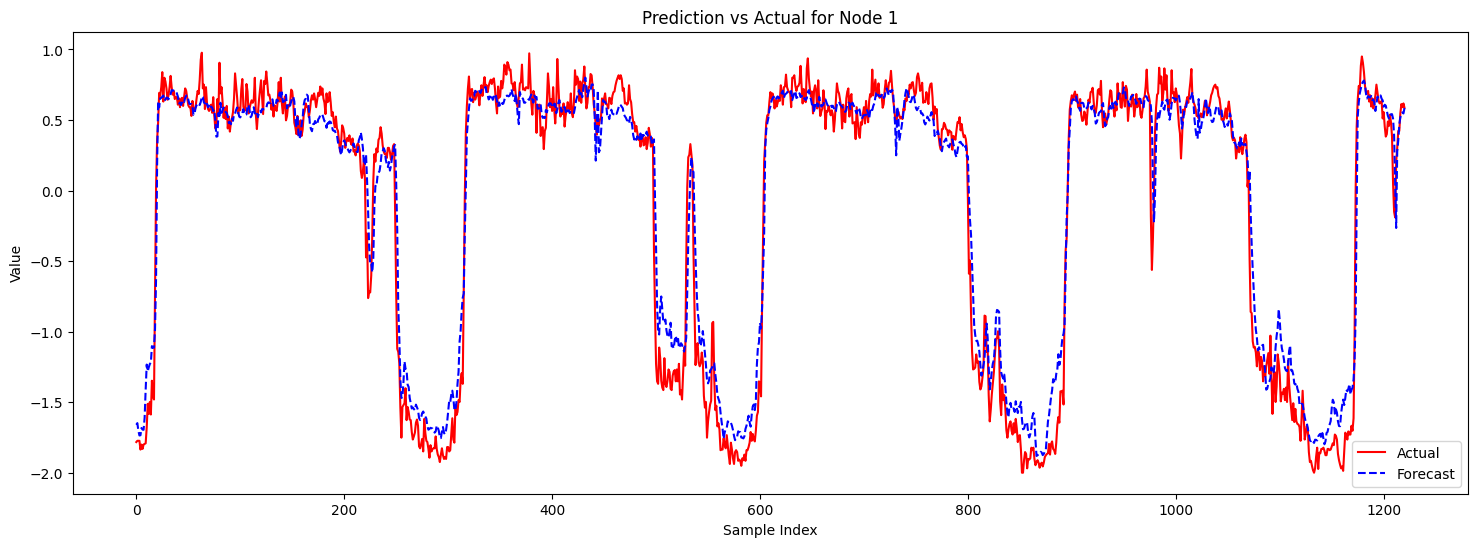

In [ ]:
# 設置模型為評估模式
model.eval()

# 初始化變數來儲存預測和真實值
all_y = []
all_y_pred = []

# 遍歷所有測試批次
with torch.no_grad():
    for x_test, y in test_loader:
        x_test, y = x_test.to(device), y.to(device)

        # 預測輸出
        y_pred = model(x_test.unsqueeze(-1), edge_index)  # Add in_feat dimension

        # 收集所有批次的真實值和預測值
        all_y.append(y.cpu().numpy())
        all_y_pred.append(y_pred.cpu().numpy())

# 將所有批次的預測值和真實值拼接起來
all_y = np.concatenate(all_y, axis=0)  # Shape: (1221, output_seq_len, num_nodes)
all_y_pred = np.concatenate(all_y_pred, axis=0)
print(all_y.shape)
print(all_y_pred.shape)

# 計算整體 MSE
model_mse = np.square(all_y_pred[:, :, :] - all_y[:, :, :]).mean()
print(f"Model MSE: {model_mse:.4f}")

# 繪圖：比較實際值與預測值
node_index = 1
plt.figure(figsize=(18, 6))
plt.plot(all_y[:, 0, node_index], label="Actual", linestyle='-', color='r')     # 第一個時間步的實際值
plt.plot(all_y_pred[:, 0, node_index], label="Forecast", linestyle='--', color='b')  # 第一個時間步的預測值
plt.legend()
plt.title(f"Prediction vs Actual for Node {node_index}")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.show()

all_y shape: (1221, 12, 228)
all_y_pred shape: (1221, 12, 228)
Model MSE (Original Scale): 41.1860
Model RMSE (Original Scale): 6.4176
Model MAE (Original Scale): 3.8082


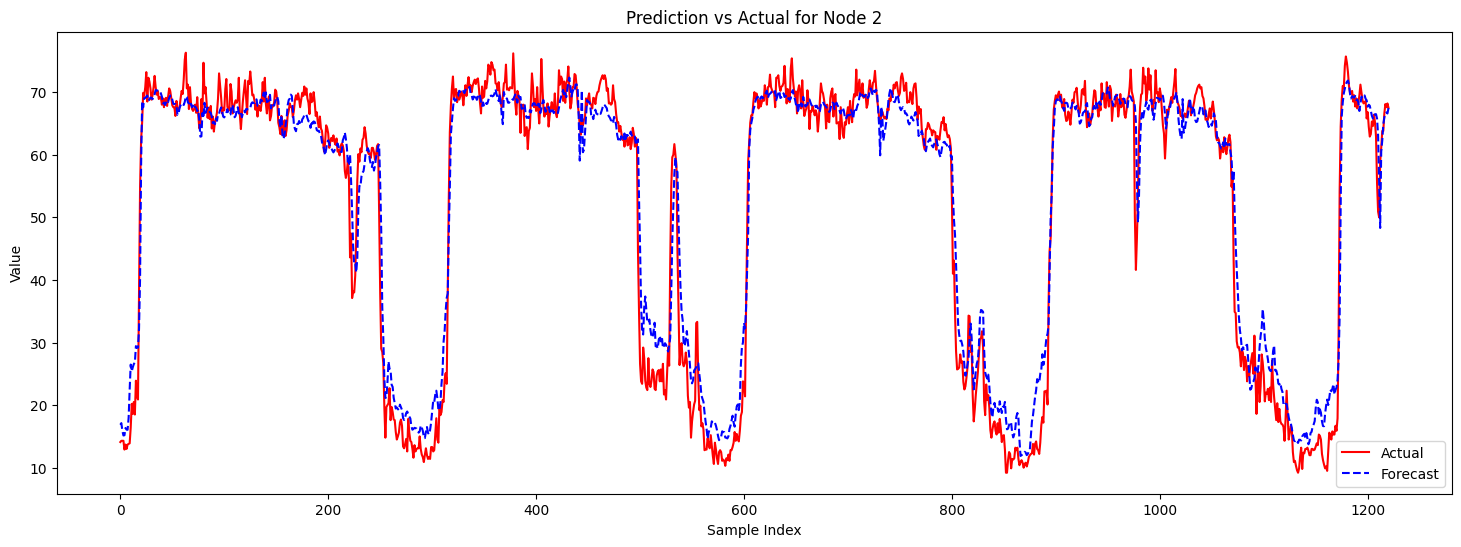

In [ ]:
# 計算 train_tensor 的 mean 和 std
num_time_steps = speeds_tensor.size(0)
num_train = int(num_time_steps * 0.7)

train_tensor_orig = speeds_tensor[:num_train]
mean = train_tensor_orig.mean(dim=0, keepdim=True)
std = train_tensor_orig.std(dim=0, keepdim=True)

mean = mean.squeeze(0)  # Shape: (num_nodes,)
std = std.squeeze(0)    # Shape: (num_nodes,)

# 轉換為 NumPy 格式
mean_np = mean.cpu().numpy()  # (num_nodes,)
std_np = std.cpu().numpy()

mean_np = mean_np.reshape(1, 1, -1)  # Shape: (1, 1, num_nodes)
std_np = std_np.reshape(1, 1, -1)    # Shape: (1, 1, num_nodes)


# 檢查形狀
print("all_y shape:", all_y.shape)  # (1221, output_seq_len, num_nodes)
print("all_y_pred shape:", all_y_pred.shape)

# 反標準化到原始尺度
all_y_orig = all_y * std_np + mean_np            # Shape: (1221, output_seq_len, num_nodes)
all_y_pred_orig = all_y_pred * std_np + mean_np  # Shape: (1221, output_seq_len, num_nodes)

# 計算 MSE（Mean Square Error）
mse = np.square(all_y_pred_orig[:, :, :] - all_y_orig[:, :, :]).mean()
rmse = np.sqrt(mse)
mae = np.abs(all_y_pred_orig[:, :, :] - all_y_orig[:, :, :]).mean()

# 輸出結果
print(f"Model MSE (Original Scale): {mse:.4f}")
print(f"Model RMSE (Original Scale): {rmse:.4f}")
print(f"Model MAE (Original Scale): {mae:.4f}")

# 繪圖：比較實際值與預測值（原始尺度）
node_index = 1
plt.figure(figsize=(18, 6))
plt.plot(all_y_orig[:, 0, node_index], label="Actual", linestyle='-', color='r')     # 第一個時間步的實際值
plt.plot(all_y_pred_orig[:, 0, node_index], label="Forecast", linestyle='--', color='b')  # 第一個時間步的預測值
plt.legend()
plt.title(f"Prediction vs Actual for Node {node_index+1}")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.show()

(12672, 228)
(1221, 228)


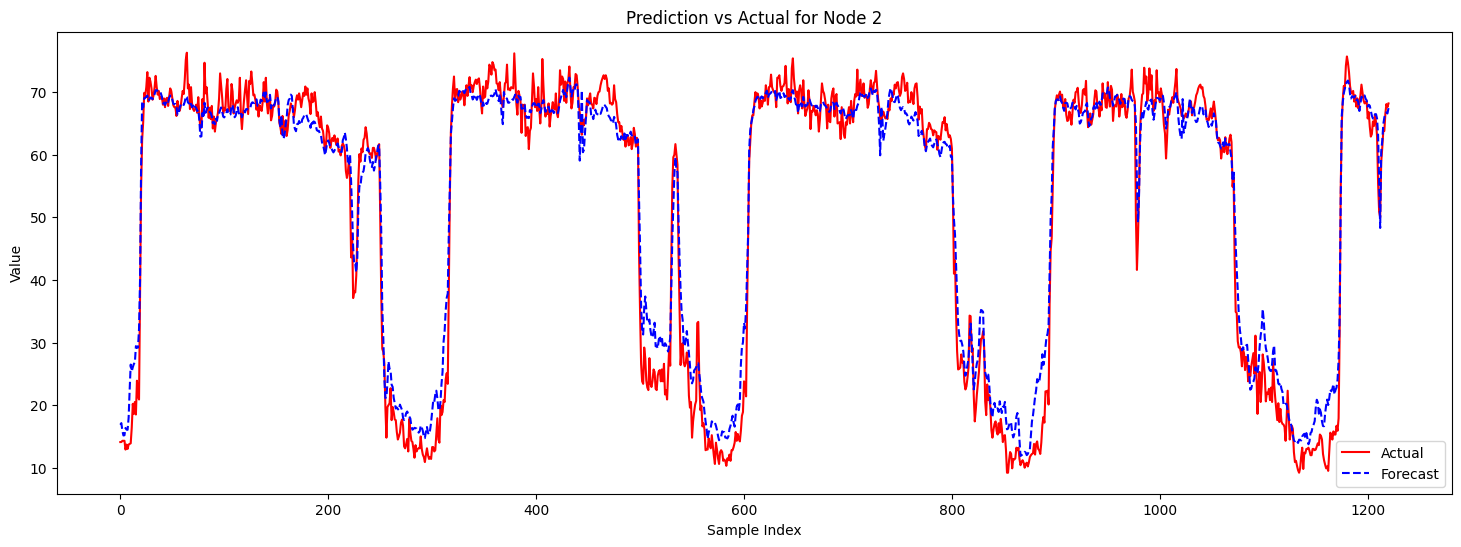

In [ ]:

print(speeds_array.shape)
test_y_data = speeds_array[11451-12:11451-12+1221, ]
print(test_y_data.shape)

node_index = 1
plt.figure(figsize=(18, 6))
plt.plot(test_y_data[ :, node_index], label="Actual", linestyle='-', color='r')     # 第一個時間步的實際值
plt.plot(all_y_pred_orig[:, 0, node_index], label="Forecast", linestyle='--', color='b')  # 第一個時間步的預測值
plt.legend()
plt.title(f"Prediction vs Actual for Node {node_index+1}")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.show()
